In [1]:
import numpy as np
import pandas as pd
import json
import pickle
import sys, os
import torch
print(torch.__version__)
from sklearn.decomposition import PCA
import matplotlib.pyplot as plt

import matplotlib.dates as mdates
import plotly.express as px

module_path = os.path.abspath(os.path.join('..'))
if module_path not in sys.path:
    sys.path.append(module_path)
print(module_path)

# from light_transformer_analysis import *
from explainability_analysis.transformer_analysis import *
from explainability_analysis.crop_spectral_signature_analysis import *
from explainability_analysis.visualization_functions import *
from explainability_analysis.visualization_constants import *

figure_results_path = "/home/luca/luca_docker/results/crop-type-classification-explainability/plots/attn_weights_patterns"
base_model_path = "/home/luca/luca_docker/results/crop-type-classification-explainability/paper"


dataset = 'BavarianCrops' # BavarianCrops
encoder = 'ltae'
loss_fn = 'rmse/'
alpha = 1.0
timestamps = ['1748960364', '1746782583']  # Concat (original LTAE), Non-concat (our LTAE)


2.0.0+cu117
/home/luca/luca_docker/crop-type-classification-explainability


In [2]:
tex_fonts_false = {
    #source: https://jwalton.info/Embed-Publication-Matplotlib-Latex/
    # Use LaTeX to write all text
    "text.usetex": False,               # --> tex package not found
    "font.family": "serif",
    # Use 10pt font in plots, to match 10pt font in document
    #"axes.labelsize": 10,
    "font.size": 10,
    # Make the legend/label fonts a little smaller
    "legend.fontsize": 8,
    "axes.titlesize": 10,
    "xtick.labelsize": 8,
    "ytick.labelsize": 8,
    'text.latex.preamble': r"\usepackage{amsmath}"
}

plt.rcParams.update(tex_fonts_false)

In [8]:
if dataset == 'BavarianCrops':
    num_classes = 12
    emb_dim = 512
    num_heads = 64
    target_classes = ["grassland","corn", "summer barley", "winter wheat", "winter barley"]
elif dataset == 'DENETHOR':
    num_classes = 9
    emb_dim = 1024
    num_heads = 32
    # target_classes = ["wheat", "rye", "barley", "oats", "corn", "root crops"]#, "oil seeds", "meadows", "forage crops"]
    target_classes = ["meadows", "forage crops", "wheat", "rye", "corn"]#, "oil seeds", "meadows", "forage crops"]

attention_head_columns = [f'Attention_H{k+1}' for k in range(num_heads)]

temporal_attn_weights, temporal_attn_date_class_avg, avg_attention_per_obs_acq_date = get_attn_weights_patterns(base_model_path, "all_dates", timestamps[1], emb_dim, num_heads, encoder, alpha, target_classes=None, dataset=dataset, concatenate_heads=False) # bias=True - 1726567787
temporal_attn_weights_concat, temporal_attn_date_class_avg_concat, avg_attention_per_obs_acq_date_concat = get_attn_weights_patterns(base_model_path, "all_dates", timestamps[0], emb_dim, num_heads, encoder, alpha, target_classes=None, dataset=dataset, concatenate_heads=True) # bias=True - 1726567787
# attn_vars = temporal_attn_weights.groupby(["Crop type", "Date"]).std(numeric_only=True).fillna(0).reset_index()

weights_outlinear_per_weight = get_out_weigths_per_attention(base_model_path, "all_dates", timestamps[1], emb_dim, num_heads, encoder, alpha, dataset=dataset)

Reading the precomputed attention weights from /home/luca/luca_docker/results/crop-type-classification-explainability/paper/12_classes/ltae/right_padding/obs_aq_date/concatenate_heads=False/layers=1,heads=64,emb_dim=512,scale_dim=8/WCE,gamma=0.0/focal_loss_ratio=100/all_dates/1746782583/predictions/attn_weights/postprocessed/parcel_temporal_attention.csv
Reading the precomputed attention weights from /home/luca/luca_docker/results/crop-type-classification-explainability/paper/12_classes/ltae/right_padding/obs_aq_date/concatenate_heads=True/layers=1,heads=64,emb_dim=512,scale_dim=8/WCE,gamma=0.0/focal_loss_ratio=100/all_dates/1748960364/predictions/attn_weights/postprocessed/parcel_temporal_attention.csv
Run training on newly implemented Lightweight Temporal Attention Encoder (LTAE)
decoder_neurons [64, 64, 12]
Initialized the transformer encoder with the following parameters: obs_aq_date/concatenate_heads=False/layers=1,heads=64,emb_dim=512,scale_dim=8
loading model from /home/luca/luc

In [ ]:
# For our LTAE model: for each crop, extract the highest weighted attention:

head_labels = {colname:colname.split('_')[1] for colname in weights_outlinear_per_weight.columns.values[1:]}
title = 'Attention Weight - coefficients $|w_i|$ by Crop Type'

class_weights_df = weights_outlinear_per_weight
class_weights_df = class_weights_df.rename(columns=head_labels)

class_weights_melted = class_weights_df.melt(id_vars="Crop type", var_name="Attention", value_name="Value")
class_weights_melted['Value'] = class_weights_melted['Value'].abs()

crop_top_heads = {} 

for crop_type in class_weights_melted['Crop type'].unique():
    crop_weights = class_weights_melted[class_weights_melted['Crop type'] == crop_type]
    top_head = crop_weights.nlargest(1, 'Value')['Attention'].item()
    crop_top_heads[crop_type] = top_head


print("Top attention head for each crop type (Our LTAE):")
display(crop_top_heads)


Top attention heads per crop type (Our LTAE):


{'fallow': 'H4',
 'grassland': 'H26',
 'winter wheat': 'H36',
 'corn': 'H62',
 'summer wheat': 'H25',
 'winter spelt': 'H23',
 'winter rye': 'H4',
 'winter barley': 'H39',
 'summer barley': 'H41',
 'summer oat': 'H18',
 'winter triticale': 'H63',
 'rapeseed': 'H38'}

Crop type: grassland - Head: H26
Crop type: corn - Head: H62
Crop type: summer barley - Head: H41
Crop type: winter wheat - Head: H36
Crop type: winter barley - Head: H39


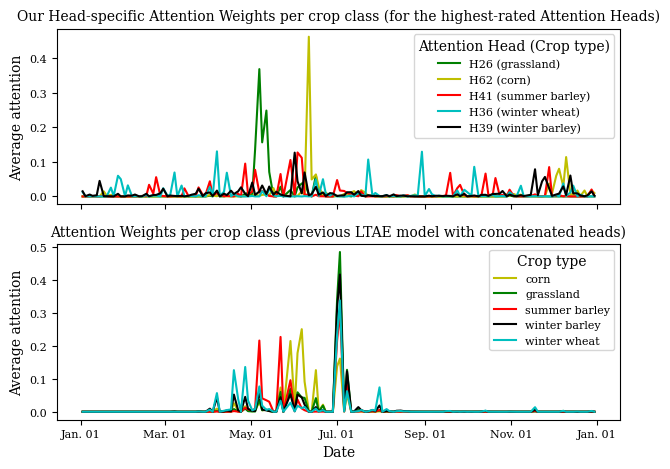

In [ ]:
# Teaser figure

CROP_TYPE_COLOR_MAPPING = {"grassland":"g", "corn": "y", "summer barley": "r", "winter barley": "k", "winter wheat": "c", "fallow":"m", "wheat":"c", "rye":"darkgoldenrod", "barley":"r", "oats":"tan", "oil seeds":"gold", "root crops":"darkorange", "meadows":"g", "forage crops":"lawngreen", "summer oat":"tan"}

# head_select = 'H18'

fig, axs = plt.subplots(2, 1, sharex=True)

# 1st subplot: our LTAE, crop-specific heads
for crop_type in target_classes:
    head_select = crop_top_heads[crop_type]
    attn_weights = temporal_attn_date_class_avg[temporal_attn_date_class_avg['Crop type'] == crop_type][['Date', 'Attention_'+head_select]].sort_values(by=['Date'])
    sns.lineplot(data=attn_weights, ax=axs[0], x="Date", y='Attention_'+head_select, label=f'{head_select} ({crop_type})', color=CROP_TYPE_COLOR_MAPPING[crop_type])

axs[0].legend(title='Attention Head (Crop type)')#, bbox_to_anchor=(1.05, 1), loc='upper left')
axs[0].set_ylabel('Average attention')  
axs[0].set_title('Our Head-specific Attention Weights per crop class (for the highest-rated Attention Heads)')  
axs[0].xaxis.set_major_formatter(DATE_FORMATTER)
axs[0].set_xlabel('Date')

# attn_data = temporal_attn_date_class_avg[temporal_attn_date_class_avg['Crop type'].isin(target_classes)][['Crop type', 'Date', 'Attention_'+head_select]]#.sort_values(by=['Crop type', 'Date'])
# sns.lineplot(data=attn_data, ax=axs[0], x="Date", y='Attention_'+head_select, hue="Crop type", palette=CROP_TYPE_COLOR_MAPPING, legend=True)

attn_data_ = temporal_attn_date_class_avg_concat[temporal_attn_date_class_avg_concat['Crop type'].isin(target_classes)][['Crop type', 'Date', 'Attention_H1']]#.sort_values(by=['Crop type', 'Date'])
sns.lineplot(data=attn_data_, ax=axs[1], x="Date", y='Attention_H1', hue="Crop type", palette=CROP_TYPE_COLOR_MAPPING, legend=True)

axs[1].set_ylabel('Average attention')  
axs[1].xaxis.set_major_formatter(DATE_FORMATTER)
# axes[-1].tick_params(axis='x', rotation=45)
axs[1].set_xlabel('Date')
axs[1].set_title('Attention Weights per crop class (previous LTAE model with concatenated heads)')  
# plt.suptitle('Average Attention Weights for crop-general heads')
plt.tight_layout()
plt.show()